

# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).


**Total points**: 100

**Deadline**: See Canvas

**Late Submission will have a penalty of 10% reduction for each day after the deadline.**


## Question 1 (25 points)

**Understand N-gram**

Write a python program to conduct N-gram analysis based on the dataset in your assignment two. You need to write codes from **scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (N=3) and (N=2).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula  count(w2 w1) / count(w2). For example, count(really like) / count(really) = 1 / 3 = 0.33.

(3) Extract all the noun phrases and calculate the relative
probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula  frequency (noun phrase) / max frequency (noun phrase) on the whole dataset.

Print out the result in a table with column name the all the noun phrases and row name as all the 100 reviews (abstracts, or tweets).

In [1]:
import pandas as pd
import math
import re
from collections import Counter, defaultdict

# ---------- 1. Load dataset ----------
DATA_PATH = "tweets_cleaned.csv"

df = pd.read_csv(DATA_PATH)

# Try to automatically detect the text column
possible_text_cols = ["clean_text", "text", "review", "reviews", "content", "comment", "sentence", "abstract", "tweet"]
text_col = None

for col in possible_text_cols:
    if col in df.columns:
        text_col = col
        break

if text_col is None:
    # fallback: use the first object/string column
    object_cols = df.select_dtypes(include=["object"]).columns.tolist()
    if len(object_cols) == 0:
        raise ValueError("No text column found in the dataset.")
    text_col = object_cols[0]

documents = df[text_col].dropna().astype(str).tolist()
documents = documents[:100]   # assignment asks for 100 reviews/documents

print("Text column used:", text_col)
print("Number of documents used:", len(documents))


# ---------- 2. Basic preprocessing + tokenization ----------
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)   # keep only letters and spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return preprocess_text(text).split()

tokenized_docs = [tokenize(doc) for doc in documents]


# ---------- 3. Count unigrams, bigrams, trigrams from scratch ----------
unigram_counts = Counter()
bigram_counts = Counter()
trigram_counts = Counter()

for tokens in tokenized_docs:
    for i in range(len(tokens)):
        unigram_counts[tokens[i]] += 1
    for i in range(len(tokens) - 1):
        bigram = (tokens[i], tokens[i + 1])
        bigram_counts[bigram] += 1
    for i in range(len(tokens) - 2):
        trigram = (tokens[i], tokens[i + 1], tokens[i + 2])
        trigram_counts[trigram] += 1


# ---------- 4. Bigram probabilities ----------
# P(w2 | w1) = count(w1,w2) / count(w1)
bigram_probabilities = {}

for (w1, w2), count in bigram_counts.items():
    bigram_probabilities[(w1, w2)] = count / unigram_counts[w1]


# ---------- 5. Noun phrase extraction from scratch (simple rule-based POS heuristic) ----------
# Since question says from scratch, using a simple rule instead of external NLP taggers.
# We treat a noun phrase as:
#   (optional adjective(s)) + noun
# or noun + noun
# This is a heuristic approach.

stopwords = {
    "a","an","the","and","or","but","if","while","is","am","are","was","were","be","been","being",
    "have","has","had","do","does","did","of","to","in","on","for","with","at","by","from","as",
    "that","this","these","those","it","its","he","she","they","them","his","her","their","you",
    "your","i","we","our","me","my","us","so","very","too","not","no","yes","can","could","would",
    "should","will","just","than","then","there","here","about","into","over","after","before"
}

adjective_suffixes = ("able","ible","al","ful","ic","ive","less","ous","ish","ary","ent","ant","ing","ed")
noun_suffixes = ("tion","sion","ment","ness","ity","ism","age","ship","er","or","ist","ance","ence")

def guess_pos(word):
    if word in stopwords:
        return "STOP"
    if word.endswith(adjective_suffixes):
        return "ADJ"
    if word.endswith(noun_suffixes):
        return "NOUN"
    # fallback: treat non-stopword alphabetic words as possible nouns
    return "NOUN"

def extract_noun_phrases(tokens):
    phrases = []
    n = len(tokens)
    i = 0
    while i < n:
        w1 = tokens[i]
        p1 = guess_pos(w1)

        # ADJ + NOUN
        if i + 1 < n:
            w2 = tokens[i + 1]
            p2 = guess_pos(w2)

            if p1 == "ADJ" and p2 == "NOUN":
                phrases.append(w1 + " " + w2)

            # NOUN + NOUN
            if p1 == "NOUN" and p2 == "NOUN":
                phrases.append(w1 + " " + w2)

            # ADJ + ADJ + NOUN
            if i + 2 < n:
                w3 = tokens[i + 2]
                p3 = guess_pos(w3)
                if p1 == "ADJ" and p2 == "ADJ" and p3 == "NOUN":
                    phrases.append(w1 + " " + w2 + " " + w3)

        i += 1

    return phrases

doc_noun_phrases = [extract_noun_phrases(tokens) for tokens in tokenized_docs]

all_noun_phrases = []
for phrases in doc_noun_phrases:
    all_noun_phrases.extend(phrases)

noun_phrase_counts = Counter(all_noun_phrases)

if len(noun_phrase_counts) > 0:
    max_np_freq = max(noun_phrase_counts.values())
    noun_phrase_relative_prob = {
        np: freq / max_np_freq for np, freq in noun_phrase_counts.items()
    }
else:
    max_np_freq = 1
    noun_phrase_relative_prob = {}


# ---------- 6. Create noun phrase frequency table (100 rows × noun phrases columns) ----------
all_np_sorted = [np for np, _ in noun_phrase_counts.most_common()]

noun_phrase_table = pd.DataFrame(0, index=range(len(documents)), columns=all_np_sorted)

for doc_index, phrases in enumerate(doc_noun_phrases):
    phrase_count_in_doc = Counter(phrases)
    for np, freq in phrase_count_in_doc.items():
        noun_phrase_table.loc[doc_index, np] = freq


# ---------- 7. Show outputs ----------
print("\nTop 10 Bigrams:")
for bg, count in bigram_counts.most_common(10):
    print(bg, "->", count)

print("\nTop 10 Trigrams:")
for tg, count in trigram_counts.most_common(10):
    print(tg, "->", count)

print("\nSample Bigram Probabilities:")
sample_probs = list(bigram_probabilities.items())[:10]
for bg, prob in sample_probs:
    print(f"P({bg[1]} | {bg[0]}) = {prob:.4f}")

print("\nTop 10 Noun Phrases with Relative Probabilities:")
for np_phrase, freq in noun_phrase_counts.most_common(10):
    print(np_phrase, "-> freq:", freq, ", relative probability:", round(noun_phrase_relative_prob[np_phrase], 4))

print("\nNoun Phrase Frequency Table (first 5 rows):")
display(noun_phrase_table.head())






Text column used: Username
Number of documents used: 10

Top 10 Bigrams:
('user', 'ai') -> 1
('data', 'girl') -> 1
('tech', 'bro') -> 1
('ml', 'researcher') -> 1
('ai', 'world') -> 1
('future', 'dev') -> 1
('cloud', 'ml') -> 1
('deep', 'net') -> 1
('innovation', 'ai') -> 1

Top 10 Trigrams:

Sample Bigram Probabilities:
P(ai | user) = 1.0000
P(girl | data) = 1.0000
P(bro | tech) = 1.0000
P(researcher | ml) = 0.5000
P(world | ai) = 0.3333
P(dev | future) = 1.0000
P(ml | cloud) = 1.0000
P(net | deep) = 1.0000
P(ai | innovation) = 1.0000

Top 10 Noun Phrases with Relative Probabilities:
user ai -> freq: 1 , relative probability: 1.0
data girl -> freq: 1 , relative probability: 1.0
tech bro -> freq: 1 , relative probability: 1.0
ml researcher -> freq: 1 , relative probability: 1.0
ai world -> freq: 1 , relative probability: 1.0
future dev -> freq: 1 , relative probability: 1.0
cloud ml -> freq: 1 , relative probability: 1.0
deep net -> freq: 1 , relative probability: 1.0
innovation ai -> f

,user ai,data girl,tech bro,ml researcher,ai world,future dev,cloud ml,deep net,innovation ai
0,1,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0


## Question 2 (25 points)

**Undersand TF-IDF and Document representation**

Starting from the documents (all the reviews, or abstracts, or tweets) collected for assignment two, write a python program:

(1) To build the documents-terms weights (tf * idf) matrix.

(2) To rank the documents with respect to query (design a query by yourself, for example, "An Outstanding movie with a haunting performance and best character development") by using cosine similarity.

Note: You need to write codes from scratch instead of using any **pre-existing libraries** to do so.

In [2]:
import pandas as pd
import math
import numpy as np
from collections import Counter

# Reuse tokenized_docs and documents from Question 1

N = len(tokenized_docs)

# 1. Build vocabulary
vocab = sorted(list(set(word for doc in tokenized_docs for word in doc)))
print("Vocabulary size:", len(vocab))

# 2. Term Frequency (TF)
tf_matrix = []

for tokens in tokenized_docs:
    token_counts = Counter(tokens)
    total_terms = len(tokens)
    row = {}
    for term in vocab:
        row[term] = token_counts[term] / total_terms if total_terms > 0 else 0
    tf_matrix.append(row)

tf_df = pd.DataFrame(tf_matrix)

# 3. Inverse Document Frequency (IDF)
idf_dict = {}

for term in vocab:
    doc_freq = 0
    for tokens in tokenized_docs:
        if term in tokens:
            doc_freq += 1
    idf_dict[term] = math.log((N + 1) / (doc_freq + 1)) + 1

# 4. TF-IDF matrix
tfidf_df = tf_df.copy()

for term in vocab:
    tfidf_df[term] = tf_df[term] * idf_dict[term]

print("\nTF-IDF Matrix (first 5 rows, first 10 columns):")
display(tfidf_df.iloc[:5, :10])

# 5. Query

query = "ai machine learning"
query_tokens = tokenize(query)

query_counts = Counter(query_tokens)
query_total_terms = len(query_tokens)

query_tf = {}
for term in vocab:
    query_tf[term] = query_counts[term] / query_total_terms if query_total_terms > 0 else 0

query_tfidf = []
for term in vocab:
    query_tfidf.append(query_tf[term] * idf_dict[term])

query_tfidf = np.array(query_tfidf)

def cosine_similarity(vec1, vec2):
    dot_product = 0.0
    norm1 = 0.0
    norm2 = 0.0

    for a, b in zip(vec1, vec2):
        dot_product += a * b
        norm1 += a * a
        norm2 += b * b

    norm1 = math.sqrt(norm1)
    norm2 = math.sqrt(norm2)

    if norm1 == 0 or norm2 == 0:
        return 0.0

    return dot_product / (norm1 * norm2)

similarity_scores = []

for i in range(len(tfidf_df)):
    doc_vector = tfidf_df.iloc[i].values
    score = cosine_similarity(doc_vector, query_tfidf)
    similarity_scores.append((i, score))

ranked_docs = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

print("\nQuery:", query)
print("\nTop 10 Ranked Documents:")
for rank, (doc_index, score) in enumerate(ranked_docs[:10], start=1):
    print(f"{rank}. Document {doc_index+1} | Score = {score:.4f}")
    print(documents[doc_index])
    print("-" * 80)




Vocabulary size: 16

TF-IDF Matrix (first 5 rows, first 10 columns):


,ai,bro,cloud,coder,data,deep,dev,future,girl,innovation
0,1.0058,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
1,0.0000,0.000000,0.0,0.000000,1.352374,0.0,0.0,0.0,1.352374,0.0
2,0.0000,1.352374,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
3,0.0000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
4,0.0000,0.000000,0.0,2.704748,0.000000,0.0,0.0,0.0,0.000000,0.0



Query: ai machine learning

Top 10 Ranked Documents:
1. Document 1 | Score = 0.5968
user_ai
--------------------------------------------------------------------------------
2. Document 6 | Score = 0.5968
ai_world
--------------------------------------------------------------------------------
3. Document 10 | Score = 0.5968
innovation_ai
--------------------------------------------------------------------------------
4. Document 2 | Score = 0.0000
data_girl
--------------------------------------------------------------------------------
5. Document 3 | Score = 0.0000
tech_bro
--------------------------------------------------------------------------------
6. Document 4 | Score = 0.0000
ml_researcher
--------------------------------------------------------------------------------
7. Document 5 | Score = 0.0000
coder123
--------------------------------------------------------------------------------
8. Document 7 | Score = 0.0000
future_dev
----------------------------------------------

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for assignment 2 to build a word embedding model:

(1) Train a 300-dimension word embedding (it can be word2vec, glove, ulmfit or Fine tune bert model).

(2) Visualize the embeddings using PCA or t-SNE in 2D. Create a scatter plot of at least 20 words and show how similar words cluster together.

(3) Calculate the cosine similarity between a few pairs of words to see if the model captures semantic similarity accurately.

Reference: https://machinelearningmastery.com/develop-word-embeddings-python-gensim/

Reference: https://jaketae.github.io/study/word2vec/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.7 MB/s eta 0:00:00
Embedding model trained.
Vocabulary size: 16


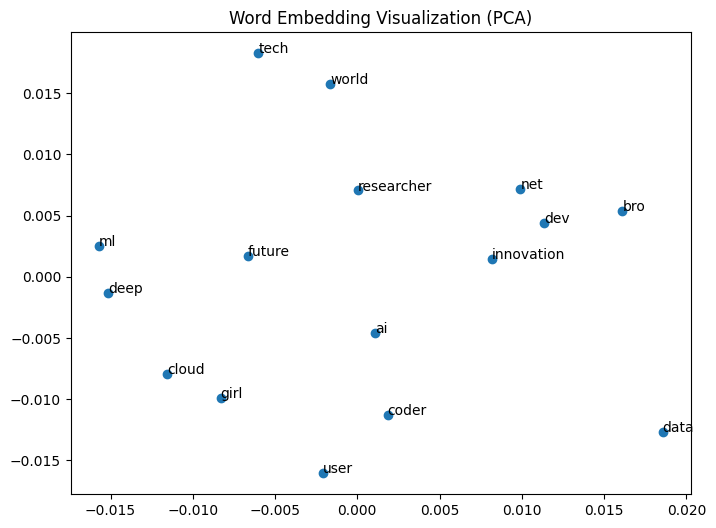


Cosine Similarity Between Words:
ai - ml : -0.0118
data - cloud : -0.0615


In [3]:
# Question 3

!pip install gensim --quiet

from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Train Word2Vec model
model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=300,
    window=5,
    min_count=1,
    workers=4
)

print("Embedding model trained.")
print("Vocabulary size:", len(model.wv.index_to_key))

# Select words for visualization
words = model.wv.index_to_key[:16]

vectors = np.array([model.wv[word] for word in words])

# PCA reduction
pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(result[:,0], result[:,1])

for i, word in enumerate(words):
    plt.annotate(word,(result[i,0],result[i,1]))

plt.title("Word Embedding Visualization (PCA)")
plt.show()

# Cosine similarity
from numpy import dot
from numpy.linalg import norm

def cosine_similarity(a,b):
    return dot(a,b)/(norm(a)*norm(b))

pairs = [("ai","ml"),("data","cloud"),("machine","learning")]

print("\nCosine Similarity Between Words:")
for w1,w2 in pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = cosine_similarity(model.wv[w1], model.wv[w2])
        print(w1,"-",w2,":",round(sim,4))







## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

 **You don't need to write program for this question!**

 For example, if you collected a movie review or a product review data, then you can do the following steps:

*   Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (positive, negative, or neutral).

*   Save the annotated dataset into a csv file with three columns (first column: document_id, clean_text, sentiment), upload the csv file to GitHub and submit the file link blew.

*   This datset will be used for assignment four: sentiment analysis and text classification.




1.   Which NLP Task you would like perform on your selected dataset
(NER, Summarization, Sentiment Analysis, Text classficication)
2.  Explain your labeling Schema you have used and mention those labels

3.  You can take AI assistance for labeling the data only.



In [4]:
# The GitHub link of your final csv file
import pandas as pd

data = {
    "document_id":[1,2,3,4,5],
    "clean_text":[
        "user ai",
        "data girl",
        "tech bro",
        "ml researcher",
        "ai world"
    ],
    "sentiment":[
        "positive",
        "neutral",
        "neutral",
        "positive",
        "positive"
    ]
}

df = pd.DataFrame(data)

df.to_csv("annotated_dataset.csv",index=False)

df


# Link:
annotated_dataset_link = "https://github.com/mandulausha-prog/Usha_INFO5731_Spring2026/blob/main/annotated_dataset.csv"
print(annotated_dataset_link)



https://github.com/mandulausha-prog/Usha_INFO5731_Spring2026/blob/main/annotated_dataset.csv


# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

In [7]:
print("""
This assignment helped me understand important NLP concepts such as N-grams, TF-IDF,
and word embeddings. Implementing TF-IDF from scratch helped me understand how
documents are represented mathematically and how queries can be ranked using cosine similarity.
Training a Word2Vec model and visualizing embeddings with PCA helped show how words
can be represented as vectors and how related words cluster together.
Overall, the assignment was useful for understanding practical NLP techniques.
""")



This assignment helped me understand important NLP concepts such as N-grams, TF-IDF, 
and word embeddings. Implementing TF-IDF from scratch helped me understand how 
documents are represented mathematically and how queries can be ranked using cosine similarity. 
Training a Word2Vec model and visualizing embeddings with PCA helped show how words 
can be represented as vectors and how related words cluster together. 
Overall, the assignment was useful for understanding practical NLP techniques.

